In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
sns.set()

In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df = df[["survived",  "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "class"]]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class
0,0,3,male,22.0,1,0,7.2500,S,Third
1,1,1,female,38.0,1,0,71.2833,C,First
2,1,3,female,26.0,0,0,7.9250,S,Third
3,1,1,female,35.0,1,0,53.1000,S,First
4,0,3,male,35.0,0,0,8.0500,S,Third


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0


In [ ]:
df["age"].fillna(df["age"].median(), inplace=True)

/tmp/ipykernel_458/3040546416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


In [ ]:
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

/tmp/ipykernel_458/3995229981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)


In [ ]:
df = pd.get_dummies(df, columns=["sex", "embarked", "class"], drop_first =True)

In [ ]:
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,class_Second,class_Third
0,0,3,22.0,1,0,7.2500,True,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,True,False,True,False,True


In [ ]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [ ]:
dt = DecisionTreeClassifier(random_state=41, max_depth=3)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=41)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88       105
           1       0.89      0.73      0.80        74

    accuracy                           0.85       179
   macro avg       0.86      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



[Text(0.5, 0.875, 'sex_male <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = Mort'),
 Text(0.25, 0.625, 'class_Third <= 0.5\ngini = 0.411\nsamples = 253\nvalue = [73, 180]\nclass = Survie'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'age <= 2.5\ngini = 0.113\nsamples = 133\nvalue = [8, 125]\nclass = Survie'),
 Text(0.0625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Mort'),
 Text(0.1875, 0.125, 'gini = 0.101\nsamples = 131\nvalue = [7, 124]\nclass = Survie'),
 Text(0.375, 0.375, 'fare <= 23.35\ngini = 0.497\nsamples = 120\nvalue = [65, 55]\nclass = Mort'),
 Text(0.3125, 0.125, 'gini = 0.494\nsamples = 94\nvalue = [42, 52]\nclass = Survie'),
 Text(0.4375, 0.125, 'gini = 0.204\nsamples = 26\nvalue = [23, 3]\nclass = Mort'),
 Text(0.75, 0.625, 'age <= 3.5\ngini = 0.31\nsamples = 459\nvalue = [371, 88]\nclass = Mort'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'sibsp <= 2.5\ngini = 0.43\nsamples = 16\nvalue = [5, 11]\nclass = Survie'),
 Text(0.

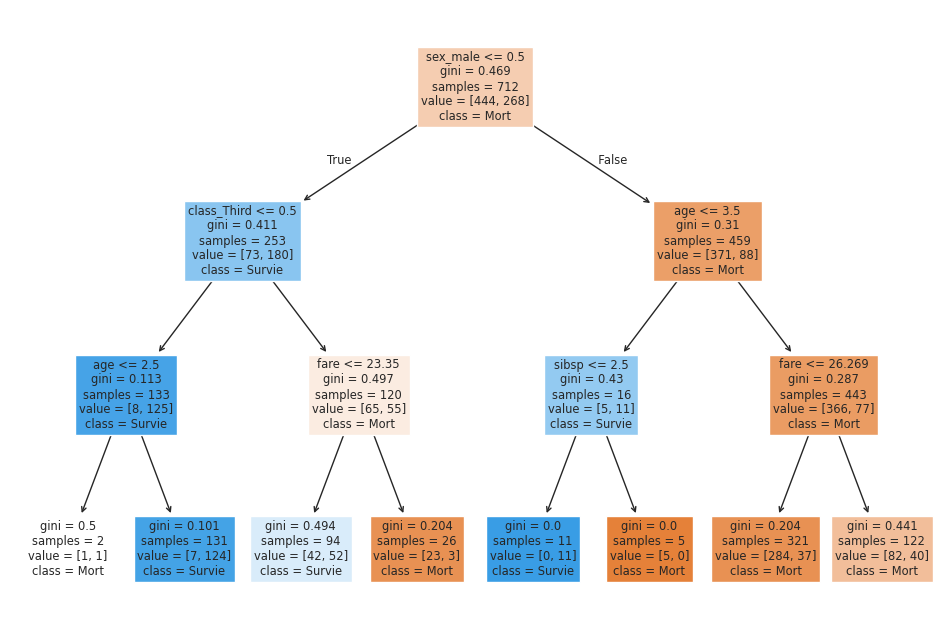

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=["Mort", "Survie"], filled=True)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the Random Forest Classifier
rf = RandomForestClassifier(random_state=41)

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.81      0.65      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



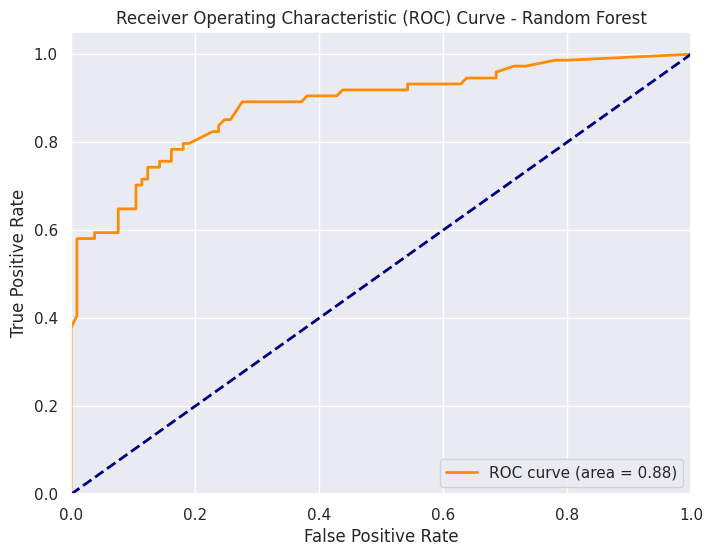

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for the positive class (class 1)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

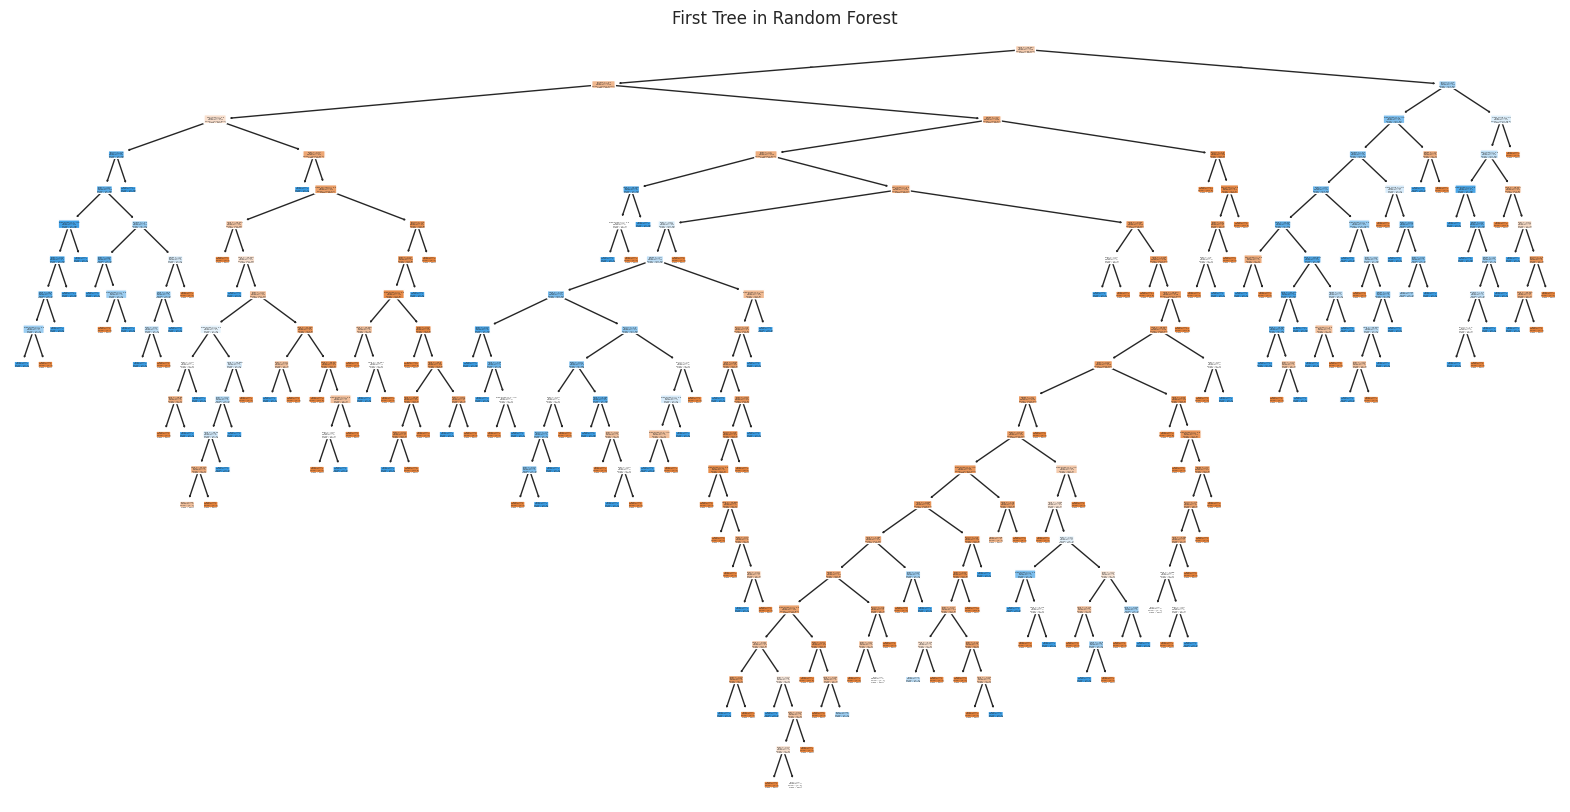

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=["Mort", "Survie"], filled=True, rounded=True)
plt.title("First Tree in Random Forest")
plt.show()

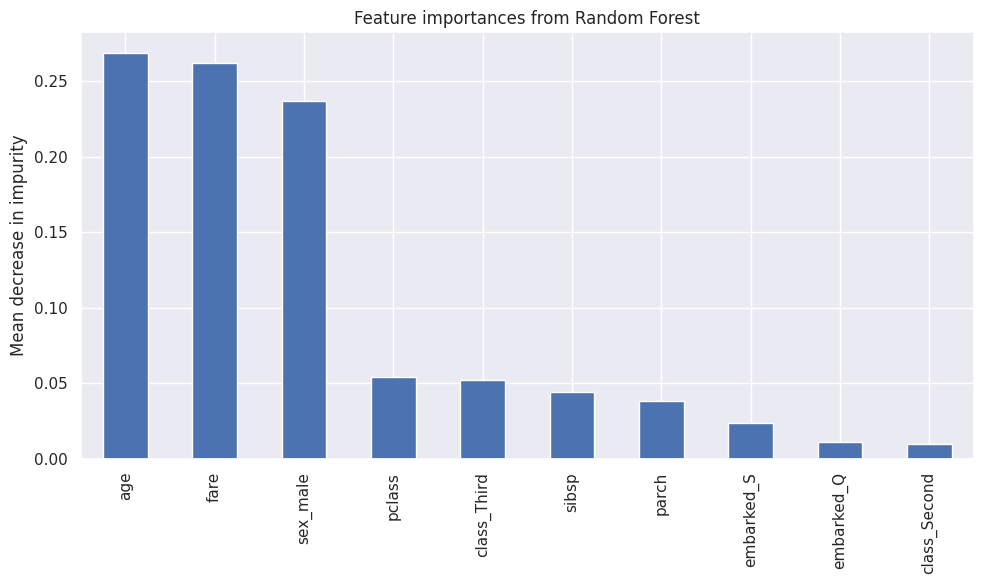

In [ ]:
importances = rf.feature_importances_
feature_names = X_train.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature importances from Random Forest")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88       105
           1       0.89      0.73      0.80        74

    accuracy                           0.85       179
   macro avg       0.86      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



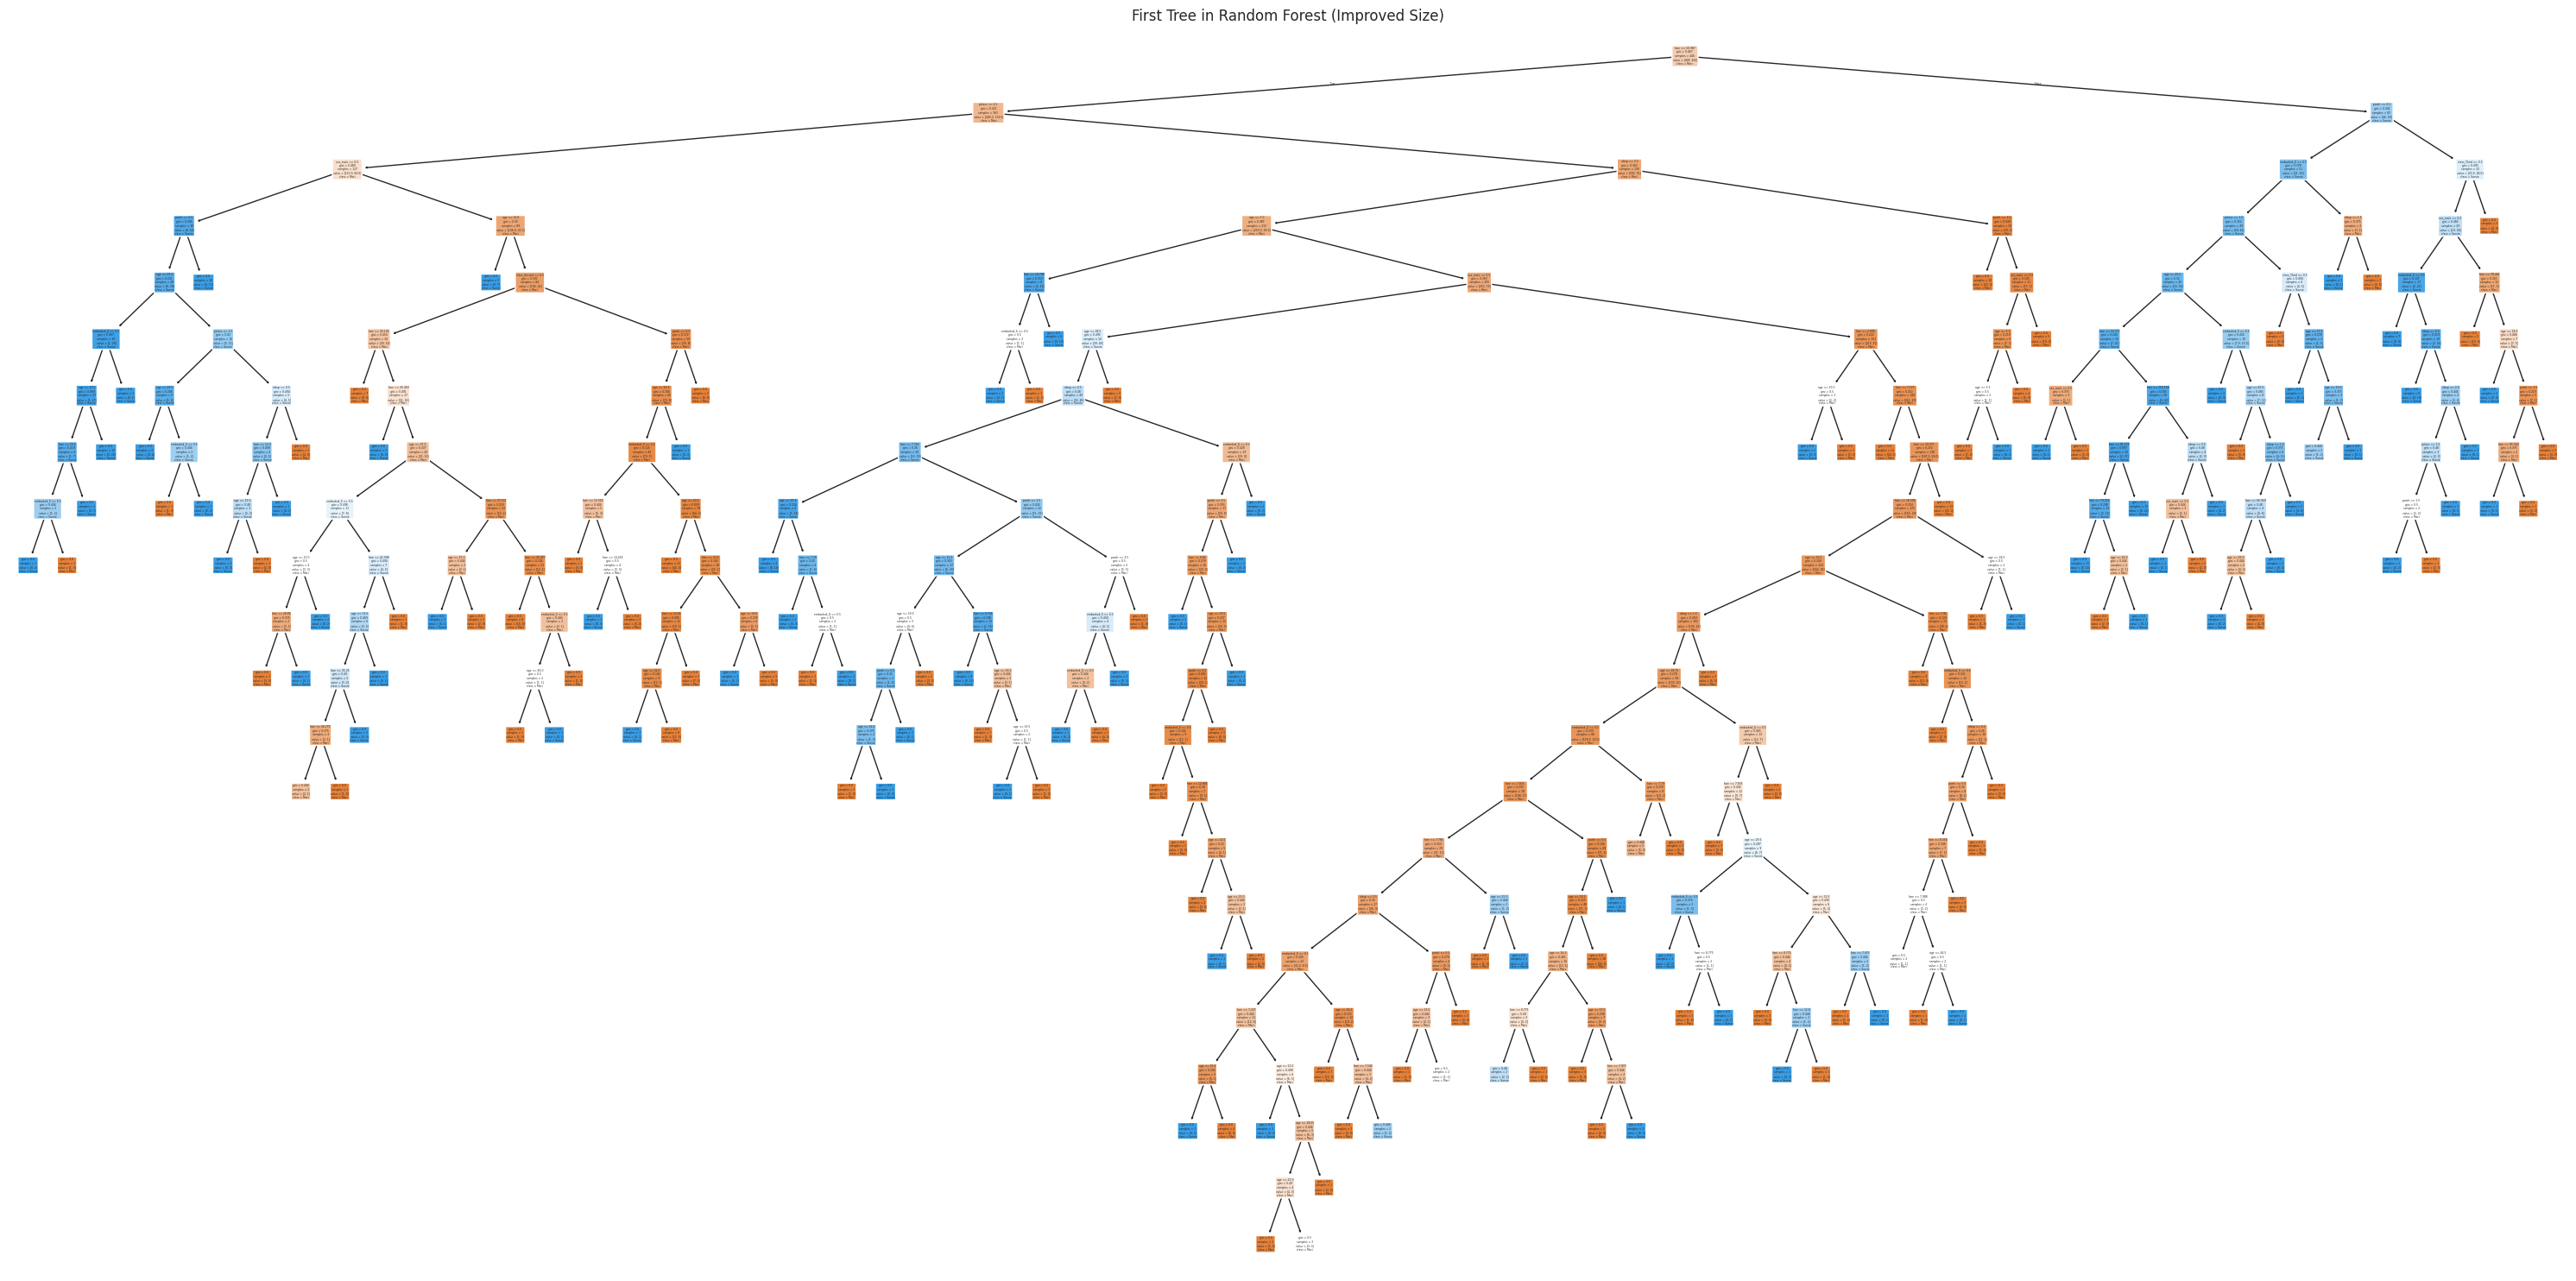

In [ ]:
plt.figure(figsize=(30, 15))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=["Mort", "Survie"], filled=True, rounded=True)
plt.title("First Tree in Random Forest (Improved Size)")
plt.tight_layout()
plt.show()

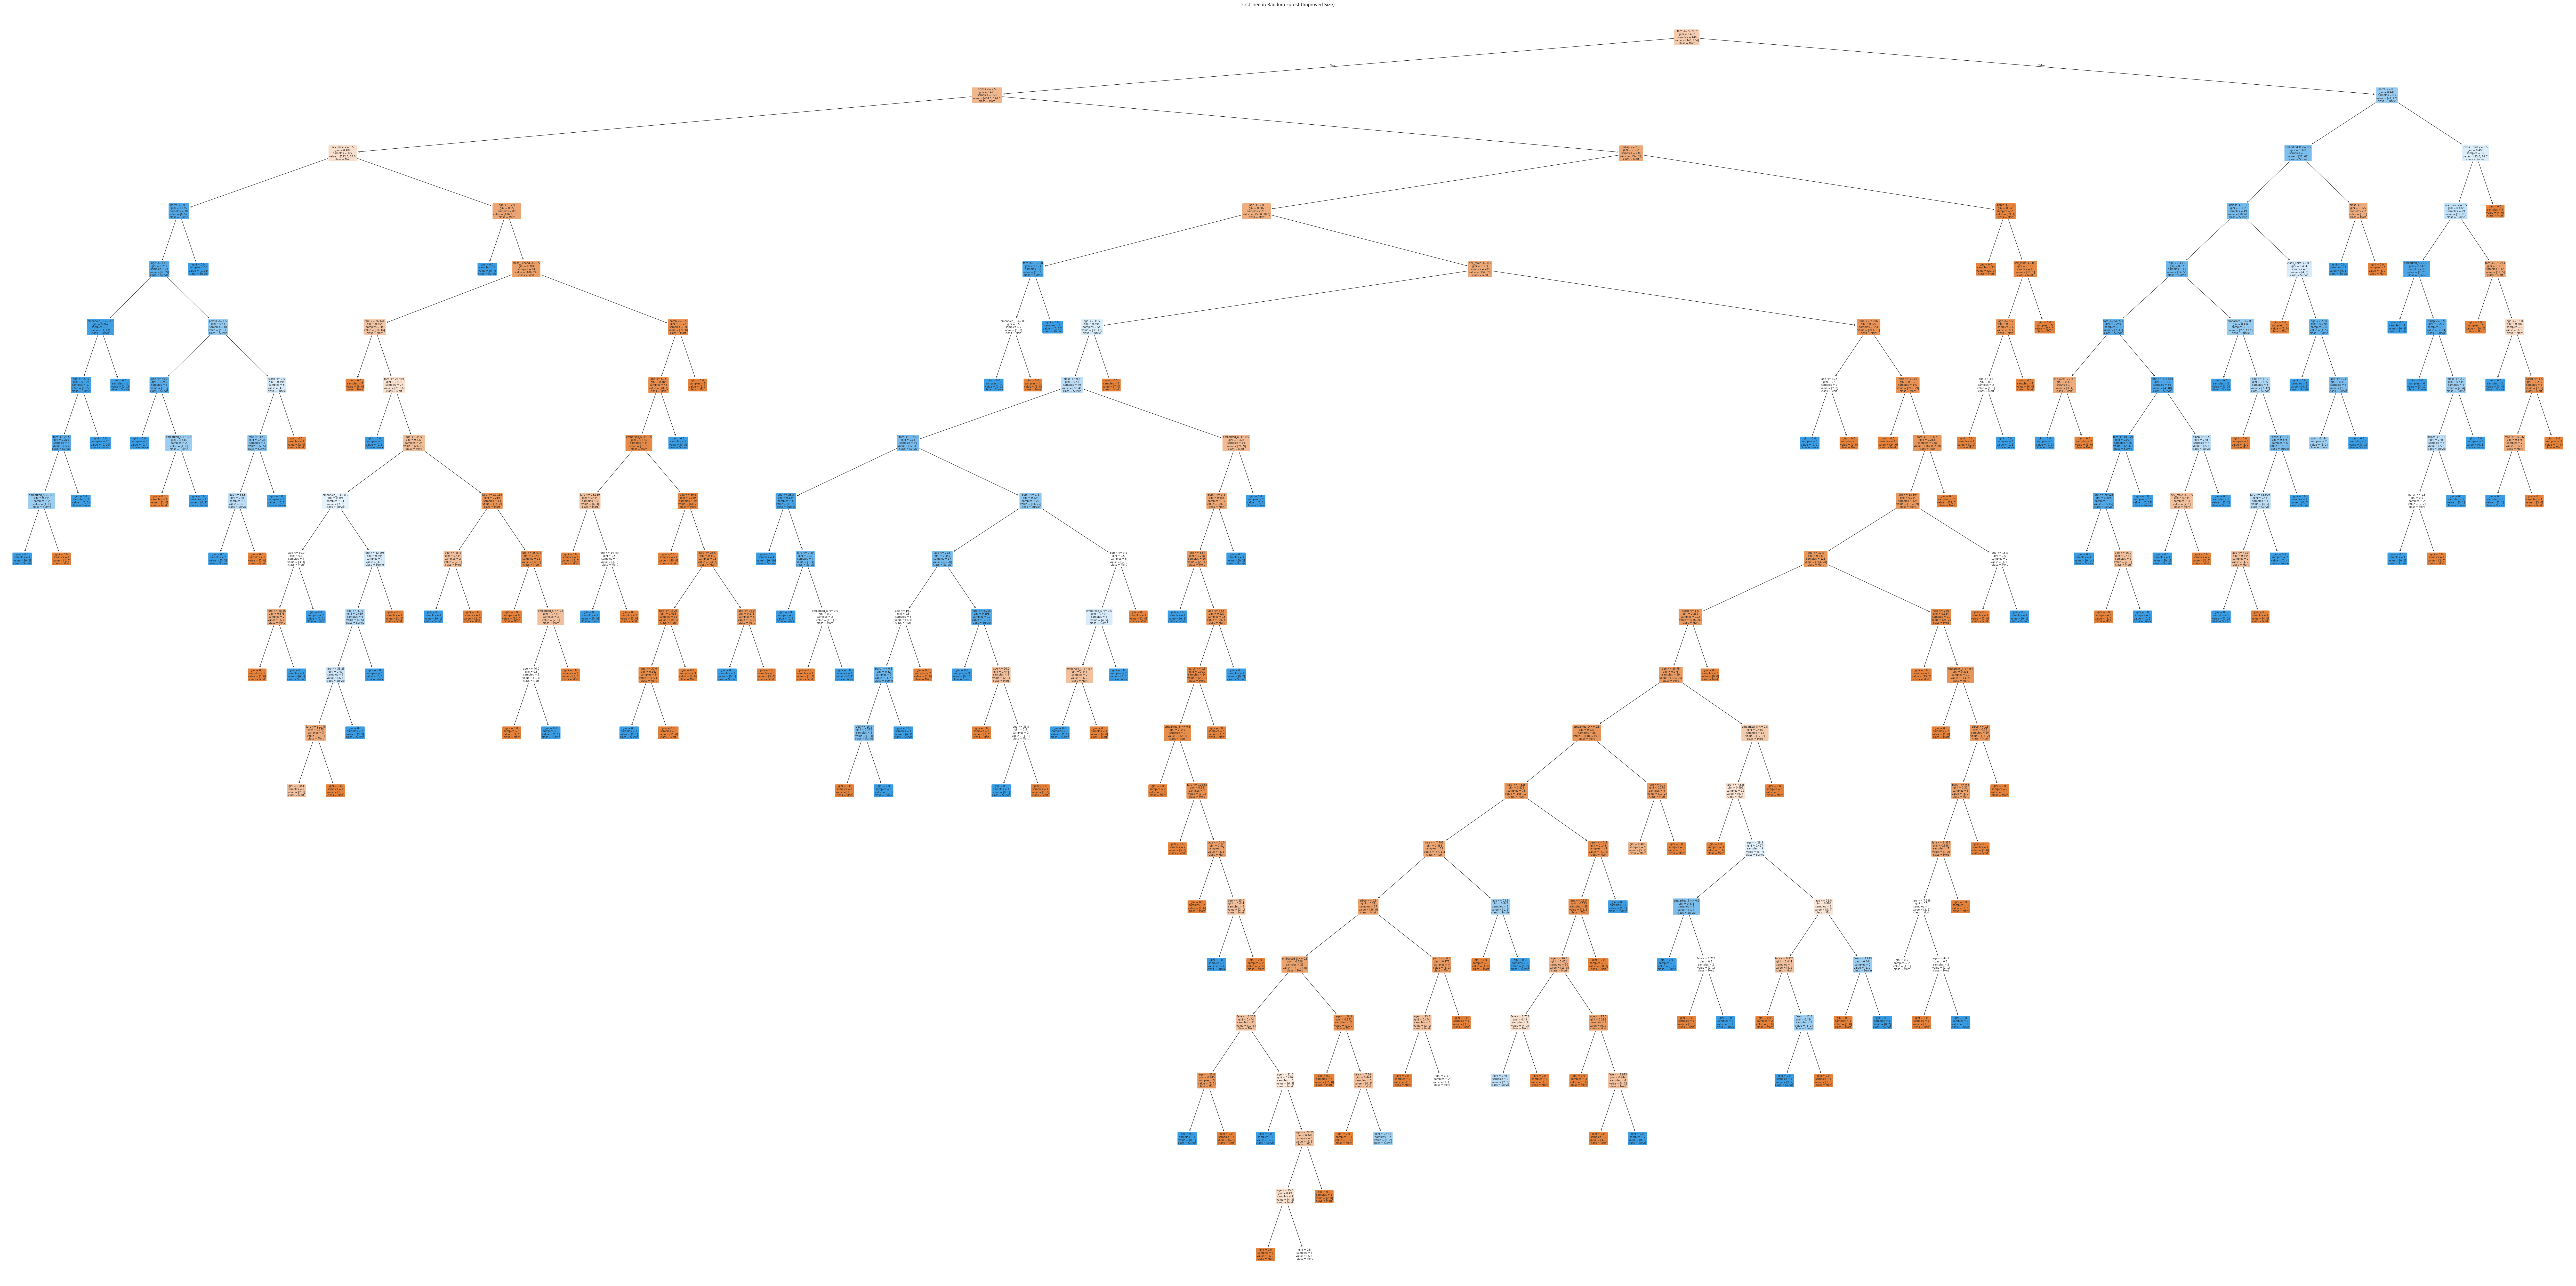

In [ ]:
plt.figure(figsize=(100, 50))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=["Mort", "Survie"], filled=True, rounded=True)
plt.title("First Tree in Random Forest (Improved Size)")
plt.tight_layout()
plt.show()